# 07 · Bite2Text — escáner intraoral → Blender → 3D Gaussian Splatting

> **Experimento.** Flujo **escáner intraoral (STL) → Blender (multivista) → 3DGS**,
> sobre el dataset **Bite2Text** (`~/anfaia/Bite2Text`), usando los **agentes de
> ingesta** del proyecto. Difiere de los notebooks 03–06 en dos cosas fijas del
> encargo: el motor de vistas es **Blender** (EEVEE, sombreado real) en vez de VTK,
> y la entrada es **STL** real de escáner, no la malla sintética.

**Cadena:** `mesh-agent` ingiere el STL al contrato → **Blender** renderiza N vistas
con pose exacta → **gsplat** entrena un campo de gaussianas → se evalúa en vistas
retenidas y se serializa al contrato (`TwinSnapshot`).

Requiere el kernel **Dental GPU (3DGS)** (torch cu128 + gsplat) y **Blender** en el
PATH. Los agentes de ingesta están instalados en ese venv (`pip install -e`).


## 0 · Entorno


In [1]:
import sys, subprocess, json, math, time
from pathlib import Path
import numpy as np, torch
from PIL import Image
import matplotlib.pyplot as plt
from gsplat import rasterization
import core_schemas, ingestion_agents

print('torch', torch.__version__, '| cuda', torch.cuda.is_available())
print('gsplat OK | ingestion_agents', ingestion_agents.__file__.split('/site-packages/')[-1])
assert torch.cuda.is_available(), 'este notebook necesita GPU (kernel Dental GPU)'
blender = subprocess.run(['blender','--version'], capture_output=True, text=True).stdout.splitlines()[0]
print(blender)


torch 2.11.0+cu128 | cuda True
gsplat OK | ingestion_agents /home/lgarbayo/agentic-smart-health/packages/ingestion-agents/src/ingestion_agents/__init__.py
Blender 5.1.1


## 1 · Ingesta del escáner con el `mesh-agent`

El escáner intraoral de Bite2Text es **STL binario** (~500k triángulos, malla
*pelada* sin color). El `mesh-agent` lo traduce al contrato: reconstruye la
topología (dedup de la sopa de triángulos), calcula normales por vértice y declara
`color_superficie = None` con **confianza 0.5** (regla del ADR 004 para STL). Es la
**frontera raw→contrato**: a partir de aquí se opera sobre el artefacto, no el STL.


In [2]:
ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / '.git').exists():
    ROOT = ROOT.parent
BITE2TEXT = Path.home() / 'anfaia' / 'Bite2Text'
CASE, JAW = 'F1980', 'lower'
scan = BITE2TEXT / CASE / 'ios' / f'ios_{JAW}.stl'
OUT = ROOT / 'data' / 'processed' / 'bite2text' / f'{CASE}_{JAW}'
OUT.mkdir(parents=True, exist_ok=True)

from ingestion_agents import ArtifactStore, MeshAgent, ReportAgent
store = ArtifactStore(ROOT / 'data' / 'processed' / 'bite2text' / '_store')

t = time.perf_counter()
mesh_out = MeshAgent(store).ingest(scan)
print(f'mesh-agent: {mesh_out.status.value} · {mesh_out.n_primitives} vértices · '
      f'{time.perf_counter()-t:.2f}s · confianza {mesh_out.provenance.confidence}')
print('surface_ref:', mesh_out.artifact_ref)
surf = store.load(mesh_out.artifact_ref)
print('artefacto:', {k: v.shape for k, v in surf.items()}, '· color?', 'colors_rgb8' in surf)


mesh-agent: ok · 255365 vértices · 0.99s · confianza 0.5
surface_ref: sha256:4c9264951677df979a8ca4ca98ee81fdb13fbcbed97c05c8ebf9fb9fbd706580
artefacto: {'positions': (255365, 3), 'faces': (508128, 3), 'normals': (255365, 3)} · color? False


### 1b · Informes clínicos con el `report-agent` (`.txt` real + `.pdf`)

Bite2Text incluye el **informe clínico** del mismo caso. Se prueban las dos cosas
que pide el entregable de ingesta:

- **(a) El informe real** (`reports_ios_en/*.txt`) es **prosa ortodóntica**
  (relaciones de clase, curvas de Spee/Wilson, apiñamiento…), **sin pH ni FDI por
  diente**. El backend determinista no extrae nada — y eso **no es un éxito vacío**:
  lo declara con confianza 0, que dispara el gate de revisión humana. Comportamiento
  correcto sobre datos reales fuera de su formato esperado.
- **(b) El camino PDF** (que la entrega nombra explícitamente): se ingiere un
  informe clínico **en PDF** con un pH → `RegionalObservation`. Demuestra que el
  `report-agent` lee PDF, no solo texto plano.


In [3]:
# (a) informe REAL de Bite2Text (.txt): prosa ortodóntica, sin pH
reports = sorted((BITE2TEXT / CASE / 'reports_ios_en').glob('*.txt'))
print('--- informe real (extracto) ---')
print(reports[0].read_text()[:280], '…\n')
rep_out = ReportAgent().ingest(reports[0])
print(f'report-agent (.txt): {rep_out.status.value} · hallazgos={len(rep_out.regional)} · '
      f'confianza {rep_out.provenance.confidence} → {rep_out.detail}')

# (b) camino PDF (entregable): informe clínico en PDF con pH → RegionalObservation
def _mini_pdf(text):
    objs=[b'<</Type/Catalog/Pages 2 0 R>>', b'<</Type/Pages/Kids[3 0 R]/Count 1>>',
          b'<</Type/Page/Parent 2 0 R/MediaBox[0 0 300 200]/Contents 4 0 R/Resources<</Font<</F1 5 0 R>>>>>>',
          None, b'<</Type/Font/Subtype/Type1/BaseFont/Helvetica>>']
    s=b'BT /F1 12 Tf 20 150 Td ('+text.encode('latin-1')+b') Tj ET'
    objs[3]=b'<</Length '+str(len(s)).encode()+b'>>stream\n'+s+b'\nendstream'
    o=b'%PDF-1.4\n'; offs=[]
    for i,ob in enumerate(objs,1): offs.append(len(o)); o+=str(i).encode()+b' 0 obj'+ob+b'endobj\n'
    x=len(o); o+=b'xref\n0 '+str(len(objs)+1).encode()+b'\n0000000000 65535 f \n'
    for f in offs: o+=('%010d 00000 n \n'%f).encode()
    o+=b'trailer<</Size '+str(len(objs)+1).encode()+b'/Root 1 0 R>>\nstartxref\n'+str(x).encode()+b'\n%%EOF'
    return o
pdf_path = OUT/'informe_demo.pdf'
pdf_path.write_bytes(_mini_pdf('Fecha: 2026-05-09 Diente 16: pH 5.4'))
pdf_out = ReportAgent().ingest(pdf_path)
print(f'report-agent (.pdf): {pdf_out.status.value} · '
      f'{[(o.region_id, o.attributes.ph) for o in pdf_out.regional]}')


--- informe real (extracto) ---
The patient presents correct transverse and vertical relationships. Sagittally, there is an end-to-end Class II molar relationship and a full Class II canine relationship on the right, and a Class I molar relationship and an end-to-end Class II canine relationship on the left, wi …

report-agent (.txt): ok · hallazgos=0 · confianza 0.0 → No se extrajo ningún hallazgo regional del informe.
report-agent (.pdf): ok · [('16', 5.4)]


### 1c · Color desde las fotos con el `image-agent`

El STL viene **pelado** (sin color). Bite2Text trae **5 fotos intraorales** con el
color real del paciente, y el `image-agent` las ingiere **sin EXIF**. El color
*exacto* por diente exige registrar cada foto contra la malla —eso es **fusión**,
fase posterior—; aquí lo llevamos de forma **regional y honesta**: se muestrea el
tono de **esmalte** y de **encía** de las fotos y se aplica por **altura** (coronas =
esmalte, margen = encía). Es color *del paciente*, plano por región, no la textura
per-píxel. El resultado se escribe como **PLY con color de vértice**, que Blender
renderiza directamente.

In [4]:
# --- § 1c · Color desde las fotos (image-agent) ---
from ingestion_agents import ImageAgent
photos = sorted((BITE2TEXT / CASE / 'intraoral-photo').glob('*.jpg'))
img_agent = ImageAgent(store)
tooth, gum = [], []
for p in photos:
    o = img_agent.ingest(p)                       # ingiere SIN EXIF
    px = store.load(o.artifact_ref)['pixels'].reshape(-1, 3).astype(np.float32)
    R, G, B = px[:,0], px[:,1], px[:,2]; val = px.max(1); red = R - 0.5*(G+B)
    tooth.append(px[(val>160) & (red>4) & (red<28) & (R>=G) & (G>=B-3)])  # crema cálido = esmalte
    gum.append(px[(red>40) & (val>70) & (val<230)])                        # rosa/rojo = encía
enamel  = np.median(np.concatenate(tooth), 0)
gingiva = np.median(np.concatenate(gum), 0)
print(f'esmalte {enamel.round().astype(int)} · encía {gingiva.round().astype(int)} '
      f'· muestreados de {len(photos)} fotos con el image-agent')

# color por altura z: coronas (z alto) = esmalte, margen (z bajo) = encía
z = surf['positions'][:, 2]
p30, p70 = np.percentile(z, [30, 70])
w = np.clip((z - p30) / (p70 - p30), 0, 1)[:, None]
vcol = (w*enamel + (1-w)*gingiva).astype(np.uint8)          # (N,3), alineado a surf['positions']

# PLY con color de vértice para que Blender lo pinte (el material lee el atributo)
scan_colored = OUT / 'scan_colored.ply'
V, F = surf['positions'].astype(np.float32), surf['faces']
with open(scan_colored, 'wb') as f:
    f.write(b'ply\nformat binary_little_endian 1.0\n')
    f.write(f'element vertex {len(V)}\n'.encode())
    f.write(b'property float x\nproperty float y\nproperty float z\n'
            b'property uchar red\nproperty uchar green\nproperty uchar blue\n')
    f.write(f'element face {len(F)}\n'.encode())
    f.write(b'property list uchar int vertex_indices\nend_header\n')
    vd = np.empty(len(V), dtype=[('x','<f4'),('y','<f4'),('z','<f4'),('r','u1'),('g','u1'),('b','u1')])
    vd['x'],vd['y'],vd['z'] = V[:,0],V[:,1],V[:,2]; vd['r'],vd['g'],vd['b'] = vcol[:,0],vcol[:,1],vcol[:,2]
    f.write(vd.tobytes())
    fd = np.empty(len(F), dtype=[('n','u1'),('a','<i4'),('b','<i4'),('c','<i4')])
    fd['n'] = 3; fd['a'],fd['b'],fd['c'] = F[:,0],F[:,1],F[:,2]
    f.write(fd.tobytes())
print('PLY coloreado →', scan_colored.name, f'({len(V)} vértices)')

esmalte [182 168 161] · encía [157 102 102] · muestreados de 5 fotos con el image-agent
PLY coloreado → scan_colored.ply (255365 vértices)


### 1d · (opcional) Color real *per-diente*: proyección de la foto oclusal

El degradado de dos tonos (§1c) es honesto pero **no distingue un diente de otro**.
Esta sonda va un paso más allá **sin resolver la fusión 6DoF**: proyecta la foto
**oclusal** (`intraoral_4`, vista cenital de la arcada) sobre la cara oclusal de la
malla y muestrea el color **por diente**.

**Cómo, sin registro real:** la huella de coronas de la malla y el anillo de dientes
de la foto son la misma «U» del mismo objeto, así que se alinean por **PCA** + el
mejor de los 4 volteos por **IoU** (solape), y se afina con un **ICP 2D**.

**Límite medido (lo importante):** el ICP **no baja del IoU ≈ 0,55**, porque el error
residual es **no-rígido** — la perspectiva de una foto intraoral sin calibrar (con
retractor). O sea: da color per-diente **real** en las coronas, pero con techo, y sale
más oscuro y con motas que el degradado (sombras entre dientes). Por eso es
**opcional y no sustituye al §1c**: escribe un PLY aparte (`*_occlusal.ply`) para
comparar. El salto de calidad de verdad —caras vestibulares, buena luz, sin
costuras— exige **multi-vista con registro real = fusión**, fase posterior.

IoU coronas<->dientes = 0.55  (techo rígido ~0.55; residuo no-rígido = perspectiva)
PLY per-diente (oclusal) -> F1980_lower_occlusal.ply


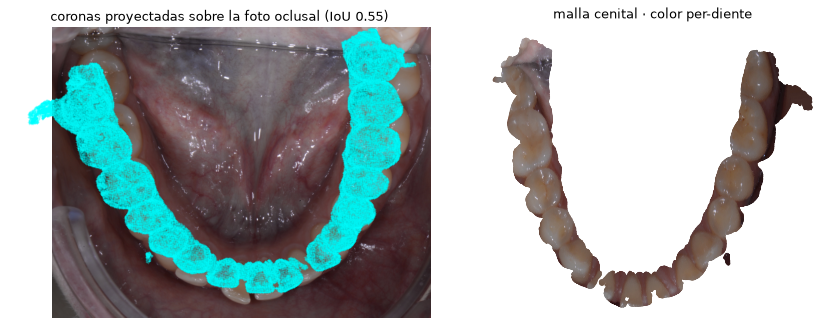

In [13]:
# --- § 1d · (opcional) Color per-diente desde la foto OCLUSAL (sonda, NO sustituye §1c) ---
# Proyecta la foto oclusal (intraoral_4) sobre las coronas y muestrea color POR DIENTE.
# Escribe un PLY aparte; el render por defecto sigue usando scan_colored.ply (§1c).
occ_photo = BITE2TEXT / CASE / 'intraoral-photo' / 'intraoral_4.jpg'   # oclusal inferior
img = store.load(img_agent.ingest(occ_photo).artifact_ref)['pixels'].astype(np.float32)
if img.ndim == 2: img = img.reshape(*Image.open(occ_photo).size[::-1], 3)
H, Wd = img.shape[:2]
R, G, B = img[..., 0], img[..., 1], img[..., 2]; vmax = img.max(-1)
# Dientes de ESTA foto: salen oscuros (~[100,75,70]) y la lengua casi igual; los
# separa el ser cálido-amarillo (no gris del retractor, no magenta de la lengua).
tooth_mask = (R - B >= 15) & (G - B >= 3) & (R - G >= 6) & (vmax > 55) & (vmax < 235)

# Coronas = mira arriba (normal +z) Y z alta -> anillo de dientes (no la ladera lingual).
zc = surf['positions'][:, 2]
occ = (surf['normals'][:, 2] > 0.20) & (zc > np.percentile(zc, 55))
mesh_xy = surf['positions'][occ, :2]

def _pca(p):
    c = p.mean(0); _, S, Vt = np.linalg.svd(p - c, full_matrices=False)
    return c, Vt, S / np.sqrt(len(p))
c_m, V_m, s_m = _pca(mesh_xy)
ys, xs = np.where(tooth_mask); tp = np.stack([xs, ys], 1).astype(np.float32)
c_p, V_p, s_p = _pca(tp)
def _proj(pts, s1, s2):                                   # malla XY -> pixel foto (con volteo)
    loc = (pts - c_m) @ V_m.T
    loc[:, 0] *= (s_p[0] / s_m[0]) * s1; loc[:, 1] *= (s_p[1] / s_m[1]) * s2
    return c_p + loc @ V_p
def _iou(q):                                              # solape coronas <-> dientes
    sc = 0.12; hh, ww = int(H * sc), int(Wd * sc)
    gx = np.clip((q[:, 0] * sc).astype(int), 0, ww - 1); gy = np.clip((q[:, 1] * sc).astype(int), 0, hh - 1)
    m = np.zeros((hh, ww), bool); m[gy, gx] = True
    t = np.asarray(Image.fromarray(tooth_mask).resize((ww, hh))) > 0
    return (m & t).sum() / max((m | t).sum(), 1)
_, s1, s2 = max((_iou(_proj(mesh_xy, a, b)), a, b) for a in (1, -1) for b in (1, -1))   # mejor volteo
q = _proj(mesh_xy, s1, s2)

# ICP 2D (similitud): parte del PCA y aprieta. NB (medido): aquí NO baja el error ->
# deja ver el techo ~0.55, porque el residuo es NO-RÍGIDO (perspectiva de foto sin calibrar).
_rng = np.random.default_rng(0)
tsub = tp[_rng.choice(len(tp), min(8000, len(tp)), replace=False)]
def _near(src):
    out = np.empty_like(src)
    for i in range(0, len(src), 3000):
        s = src[i:i + 3000]
        d = (s[:, None, 0] - tsub[None, :, 0]) ** 2 + (s[:, None, 1] - tsub[None, :, 1]) ** 2
        out[i:i + 3000] = tsub[d.argmin(1)]
    return out
def _umeyama(X, Y):
    mX, mY = X.mean(0), Y.mean(0); U, D, Vt = np.linalg.svd(((Y - mY).T @ (X - mX)) / len(X))
    S = np.eye(2); S[1, 1] = np.sign(np.linalg.det(U @ Vt))
    Rm = U @ S @ Vt; s = np.trace(np.diag(D) @ S) / (((X - mX) ** 2).sum() / len(X))
    return s, Rm, mY - s * (Rm @ mX)
qi = _rng.choice(len(q), min(4000, len(q)), replace=False)
for _ in range(20):
    qs = q[qi]; tg = _near(qs); dd = np.hypot(*(qs - tg).T); m = dd <= np.percentile(dd, 80)
    s, Rm, t = _umeyama(qs[m], tg[m]); q = (s * (q @ Rm.T)) + t
iou = _iou(q)
print(f'IoU coronas<->dientes = {iou:.2f}  (techo rígido ~0.55; residuo no-rígido = perspectiva)')

# Muestrear color y mezclar SOBRE el degradado (§1c) solo en las coronas (costura suave).
qx = np.clip(q[:, 0].round().astype(int), 0, Wd - 1); qy = np.clip(q[:, 1].round().astype(int), 0, H - 1)
samp = img[qy, qx]
vcol_occ = vcol.astype(np.float32).copy()
wz = np.clip((surf['normals'][occ, 2] - 0.20) / 0.5, 0, 1)[:, None]
vcol_occ[occ] = wz * samp + (1 - wz) * vcol_occ[occ]
vcol_occ = vcol_occ.clip(0, 255).astype(np.uint8)

# PLY aparte — NO pisa scan_colored.ply del §1c.
scan_occlusal = OUT / f'{CASE}_{JAW}_occlusal.ply'
V, Fc = surf['positions'].astype(np.float32), surf['faces']
with open(scan_occlusal, 'wb') as f:
    f.write(b'ply\nformat binary_little_endian 1.0\n'); f.write(f'element vertex {len(V)}\n'.encode())
    f.write(b'property float x\nproperty float y\nproperty float z\n'
            b'property uchar red\nproperty uchar green\nproperty uchar blue\n')
    f.write(f'element face {len(Fc)}\n'.encode()); f.write(b'property list uchar int vertex_indices\nend_header\n')
    vd = np.empty(len(V), dtype=[('x', '<f4'), ('y', '<f4'), ('z', '<f4'), ('r', 'u1'), ('g', 'u1'), ('b', 'u1')])
    vd['x'], vd['y'], vd['z'] = V[:, 0], V[:, 1], V[:, 2]
    vd['r'], vd['g'], vd['b'] = vcol_occ[:, 0], vcol_occ[:, 1], vcol_occ[:, 2]; f.write(vd.tobytes())
    fd = np.empty(len(Fc), dtype=[('n', 'u1'), ('a', '<i4'), ('b', '<i4'), ('c', '<i4')]); fd['n'] = 3
    fd['a'], fd['b'], fd['c'] = Fc[:, 0], Fc[:, 1], Fc[:, 2]; f.write(fd.tobytes())
print('PLY per-diente (oclusal) ->', scan_occlusal.name)

# Diagnóstico: proyección sobre la foto + malla cenital coloreada per-diente.
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].imshow(img.astype(np.uint8)); ax[0].scatter(q[:, 0], q[:, 1], s=0.2, c='cyan', alpha=0.25)
ax[0].set_title(f'coronas proyectadas sobre la foto oclusal (IoU {iou:.2f})'); ax[0].axis('off')
ax[1].scatter(surf['positions'][occ, 0], surf['positions'][occ, 1], s=0.4, c=samp / 255.0)
ax[1].set_aspect('equal'); ax[1].set_title('malla cenital · color per-diente'); ax[1].axis('off')
plt.tight_layout(); plt.show()

## 2 · Vistas multivista con **Blender** (EEVEE)

`scripts/blender_render_views.py` corre Blender *headless*: importa la malla
**coloreada** (§1c), la normaliza (centra + escala a caja unidad), lleva el
**color de vértice** (esmalte/encía) al material y le pone una luz de casco
(iluminación consistente entre vistas), y orbita una cámara escribiendo cada vista
con su **pose exacta** en `transforms.json` (convención NeRF-blender). Sin COLMAP:
la pose sale del propio grafo de escena.

In [5]:
N_VIEWS, RES = 1600, 1024
t = time.perf_counter()
r = subprocess.run([
    'blender','--background','--python', str(ROOT/'scripts'/'blender_render_views.py'),'--',
    '--scan', str(scan_colored), '--out', str(OUT), '--views', str(N_VIEWS), '--res', str(RES),
    '--samples','16','--elevations','8'], capture_output=True, text=True)
print(r.stdout.strip().splitlines()[-1] if r.stdout else r.stderr[-400:])
print(f'Blender: {time.perf_counter()-t:.1f}s')
T = json.loads((OUT/'transforms.json').read_text())
print('vistas:', len(T['frames']), '· fov_x', round(T['camera_angle_x'],3), '· scan_scale', round(T['scan_scale'],4))

Blender quit
Blender: 230.2s
vistas: 1600 · fov_x 0.698 · scan_scale 0.0291


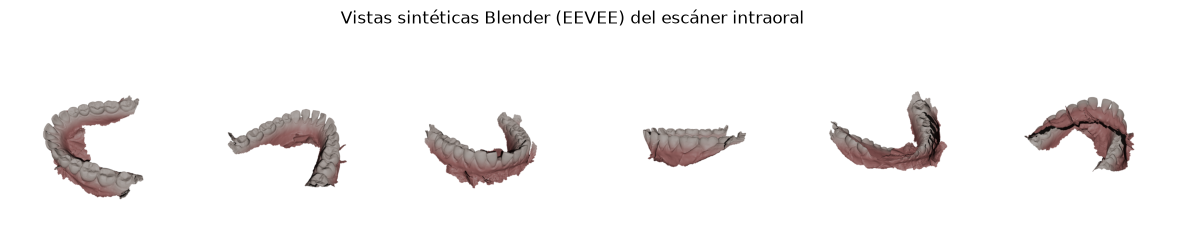

In [6]:
# galería de las primeras vistas Blender
fig, ax = plt.subplots(1, 6, figsize=(15, 2.6))
for i, a in enumerate(ax):
    im = Image.open(OUT / T['frames'][i* (len(T['frames'])//6)]['file_path'])
    a.imshow(im); a.axis('off')
fig.suptitle('Vistas sintéticas Blender (EEVEE) del escáner intraoral', y=1.02); plt.show()


## 3 · Inicialización del campo desde la superficie ingerida

Las gaussianas se siembran en puntos muestreados de la **malla del `mesh-agent`**
(no de una nube aparte), con la **misma normalización** que aplicó Blender —así el
campo inicial cae exactamente sobre la geometría renderizada.


In [7]:
dev = 'cuda'
P = surf['positions'].astype(np.float32)
c = (P.min(0) + P.max(0)) / 2
P = (P - c) * (2.0 / (P.max(0) - P.min(0)).max())          # idéntica a Blender
rng = np.random.default_rng(0)
sel = rng.choice(len(P), min(150000, len(P)), replace=False)
means0 = torch.tensor(P[sel], device=dev)
N0 = means0.shape[0]
d = torch.cdist(means0[:2000], means0[:2000]).topk(4, largest=False).values[:,1:].mean()
# Color inicial: el muestreado de las fotos por el image-agent (§1c), no un gris
# constante — el campo arranca ya con el tono del paciente y el 3DGS solo lo refina.
col0 = torch.tensor(vcol[sel] / 255.0, dtype=torch.float32, device=dev).clamp(0.01, 0.99)
# Parametros en un ParameterDict con un optimizador POR clave: es lo que el
# DefaultStrategy necesita para anadir/quitar filas (densificar y podar) sin
# descuadrar el estado de Adam.
params = torch.nn.ParameterDict({
    'means':     torch.nn.Parameter(means0),
    'scales':    torch.nn.Parameter(torch.log(torch.full((N0, 3), float(d), device=dev))),
    'quats':     torch.nn.Parameter(torch.tensor([1., 0, 0, 0], device=dev).repeat(N0, 1)),
    'opacities': torch.nn.Parameter(torch.logit(torch.full((N0,), 0.1, device=dev))),
    'colors':    torch.nn.Parameter(torch.logit(col0)),
}).to(dev)
print(f'{N0} gaussianas sembradas desde la superficie del mesh-agent (color de las fotos)')

150000 gaussianas sembradas desde la superficie del mesh-agent (color de las fotos)


## 4 · Entrenamiento 3DGS (`gsplat`) — SSIM + control de densidad

Cámara: la pose de Blender (OpenGL) se convierte a la convención OpenCV de gsplat.
Se aparta **1 de cada 4** vistas como *holdout* y se mide el **PSNR** ahí.

**Pérdida `0,8·L1 + 0,2·(1−SSIM)`** (la del 3DGS de referencia): la L1 da la fidelidad
global; la **SSIM** premia la **estructura local** (bordes, contraste) y evita el
resultado borroso de la L1 sola → dientes más nítidos.

Además, **control adaptativo de densidad** (`DefaultStrategy`): densificación suave,
poda y reset de opacidad — técnica explicada en
[`docs/research/3dgs-adaptive-density-control.md`](../docs/research/3dgs-adaptive-density-control.md).

> **Nota (medido).** El reset+poda **no** sube la opacidad en este campo mate (la
> baja opacidad es el óptimo con L1 sobre fondo negro). Pero renderizando se comprobó
> que **cortar por opacidad no desmantela el campo**: la superficie la sostiene la
> minoría opaca, así que el visor descarta la neblina de baja opacidad con umbral de
> alfa **~8/255** y los bordes quedan limpios (adiós "pelillos"). La SSIM ataca la
> **nitidez**; el umbral de alfa, la **neblina**.

In [8]:
from gsplat import DefaultStrategy
from torchmetrics.functional import structural_similarity_index_measure as ssim
W = H = T['w']
fx = 0.5 * W / math.tan(0.5 * T['camera_angle_x'])
K = torch.tensor([[fx,0,W/2],[0,fx,H/2],[0,0,1]], dtype=torch.float32, device=dev)
flip = torch.tensor([[1,0,0,0],[0,-1,0,0],[0,0,-1,0],[0,0,0,1]], dtype=torch.float32)  # GL->CV
# A 1024 px las 1600 imagenes no caben en RAM (~20 GB): carga BAJO DEMANDA.
viewmats = torch.stack([
    torch.linalg.inv(torch.tensor(fr['transform_matrix'], dtype=torch.float32) @ flip)
    for fr in T['frames']]).to(dev)
def load_img(k):
    rgba = np.asarray(Image.open(OUT/T['frames'][k]['file_path']).convert('RGBA'), np.float32)/255.0
    return torch.from_numpy(rgba[...,:3]*rgba[...,3:4]).to(dev)   # sobre negro
idx = np.arange(len(T['frames'])); test = idx[::4]; train = np.setdiff1d(idx, test)
rng2 = np.random.default_rng(1)
eval_test = rng2.choice(test, min(24, len(test)), replace=False)
eval_train = rng2.choice(train, min(24, len(train)), replace=False)
print(f'{len(train)} train . {len(test)} holdout . PSNR sobre {len(eval_test)} retenidas @ {W}px')

def render(vm):
    out, _, info = rasterization(params['means'], torch.nn.functional.normalize(params['quats'], dim=-1),
        torch.exp(params['scales']), torch.sigmoid(params['opacities']), torch.sigmoid(params['colors']),
        vm[None], K[None], W, H, packed=False)
    return out[0], info
def psnr_at(js):
    with torch.no_grad():
        return float(np.mean([-10*math.log10(((render(viewmats[j])[0]-load_img(j))**2).mean().item()+1e-10) for j in js]))

# Un optimizador Adam POR parametro (lo exige el DefaultStrategy).
lr = {'means':1e-3,'scales':5e-3,'quats':1e-3,'opacities':5e-2,'colors':1e-2}
opt = {k: torch.optim.Adam([v], lr=lr[k]) for k, v in params.items()}

# Control adaptativo de densidad (Kerbl et al. 2023): densificacion SUAVE —el init
# de malla ya es denso—, PODA de gaussianas casi transparentes y RESET periodico de
# opacidad. El reset+poda evita la 'neblina' de baja opacidad y deja un campo opaco
# que se ve en cualquier visor al umbral estandar.
strat = DefaultStrategy(refine_start_iter=500, refine_stop_iter=3000,
                        reset_every=1500, refine_every=100, verbose=False)
strat.check_sanity(params, opt); state = strat.initialize_state(scene_scale=1.0)

torch.manual_seed(0); ITERS = 6000; curve=[]
t=time.perf_counter()
for it in range(ITERS):
    i = int(np.random.choice(train))
    out, info = render(viewmats[i])
    strat.step_pre_backward(params, opt, state, it, info)
    tgt = load_img(i)
    a = out.permute(2,0,1).unsqueeze(0); b = tgt.permute(2,0,1).unsqueeze(0)
    loss = 0.8*(out-tgt).abs().mean() + 0.2*(1.0 - ssim(a, b, data_range=1.0))  # 3DGS de referencia
    for o in opt.values(): o.zero_grad()
    loss.backward()
    for o in opt.values(): o.step()
    strat.step_post_backward(params, opt, state, it, info, packed=False)
    if it % 500 == 0 or it == ITERS-1:
        ptr, pt = psnr_at(eval_train), psnr_at(eval_test)
        curve.append((it, ptr, pt))
        print(f'it {it:5d}  N={params["means"].shape[0]:>7}  loss {loss.item():.4f}  train {ptr:.2f}  holdout {pt:.2f} dB')
Nfinal = params['means'].shape[0]
print(f'entrenamiento: {time.perf_counter()-t:.1f}s . {Nfinal} gaussianas finales')


1200 train . 400 holdout . PSNR sobre 24 retenidas @ 1024px


/home/lgarbayo/.venvs/dental-gpu/lib/python3.13/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


it     0  N= 150000  loss 0.0592  train 16.98  holdout 16.86 dB


it   500  N= 150000  loss 0.0280  train 26.71  holdout 26.61 dB


it  1000  N= 148334  loss 0.0164  train 28.16  holdout 27.82 dB


...

it  4000  N= 130485  loss 0.0161  train 31.16  holdout 30.79 dB


it  4500  N= 130485  loss 0.0137  train 31.42  holdout 31.09 dB


it  5000  N= 130485  loss 0.0159  train 31.48  holdout 31.30 dB


it  5500  N= 130485  loss 0.0127  train 31.90  holdout 31.51 dB


it  5999  N= 130485  loss 0.0121  train 31.91  holdout 31.50 dB
entrenamiento: 187.8s . 130485 gaussianas finales


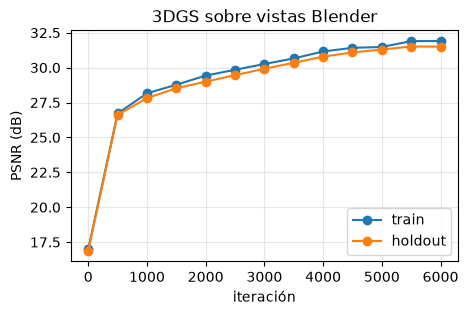

In [9]:
c = np.array(curve)
plt.figure(figsize=(5,3))
plt.plot(c[:,0], c[:,1], '-o', label='train'); plt.plot(c[:,0], c[:,2], '-o', label='holdout')
plt.xlabel('iteración'); plt.ylabel('PSNR (dB)'); plt.legend(); plt.title('3DGS sobre vistas Blender'); plt.grid(alpha=.3); plt.show()


## 5 · Comparación + serialización al contrato

Vista **retenida** real (Blender) vs. render del 3DGS entrenado, y ensamblado de un
`TwinSnapshot`: `surface_ref` del `mesh-agent` + `gaussian_field_ref` del campo
entrenado (guardado por hash en el `ArtifactStore`). El pH del `report-agent` iría
en `regional` (aquí vacío: el informe no lo trae).


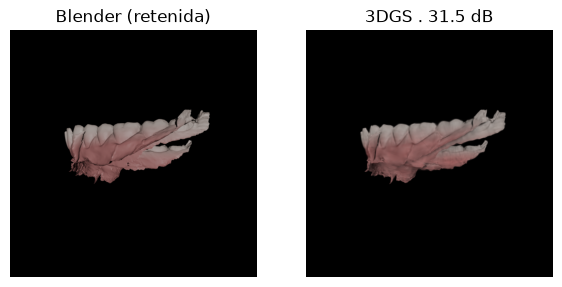

In [10]:
j = int(test[len(test)//2])
with torch.no_grad(): pred = render(viewmats[j])[0].clamp(0,1).cpu().numpy()
fig, ax = plt.subplots(1,2, figsize=(7,3.5))
ax[0].imshow(load_img(j).cpu().numpy()); ax[0].set_title('Blender (retenida)'); ax[0].axis('off')
ax[1].imshow(pred); ax[1].set_title(f'3DGS . {curve[-1][2]:.1f} dB'); ax[1].axis('off'); plt.show()


In [11]:
from datetime import datetime, timezone
from core_schemas import TwinSnapshot, Provenance, Modality
with torch.no_grad():
    field_ref = store.put(
        centers=params['means'].detach().cpu().numpy(),
        scales=torch.exp(params['scales']).detach().cpu().numpy(),
        rotations=torch.nn.functional.normalize(params['quats'], dim=-1).detach().cpu().numpy(),
        opacity=torch.sigmoid(params['opacities']).detach().cpu().numpy(),
        color=torch.sigmoid(params['colors']).detach().cpu().numpy())
snap = TwinSnapshot(
    acquisition_id=f'{CASE}_{JAW}', timestamp=datetime.now(timezone.utc),
    modalities=[Modality.MESH], ingestion=[mesh_out.ingestion],
    gaussian_field_ref=field_ref, surface_ref=mesh_out.artifact_ref, n_primitives=Nfinal,
    provenance=Provenance(source_file=str(scan), modality=Modality.MESH,
                          agent='notebook-07@0.1.0', confidence=mesh_out.provenance.confidence))
(OUT/'twin_snapshot.json').write_text(json.dumps(snap.model_dump(mode='json'), indent=1, ensure_ascii=False))
print('TwinSnapshot', snap.schema_version, '. surface_ref', snap.surface_ref[:24], '. field_ref', snap.gaussian_field_ref[:24])


TwinSnapshot 1.2.0 . surface_ref sha256:4c9264951677df979 . field_ref sha256:4d4b814b2ad31e541


### 5b · Export `.ply` para el visor web (formato INRIA)

El campo se guarda como `.npz` en el `ArtifactStore` (celda anterior, trazable por
hash). El **visor web** (`@mkkellogg/gaussian-splats-3d`) consume `.ply` en formato
**INRIA** (grado 0 de armónicos = color RGB plano): aquí se **invierten las
activaciones** (opacidad→logit, escala→log, color→coeficiente DC de SH) para que el
visor las reaplique y muestre lo mismo que gsplat. Este es el artefacto que va a
`dental-3dgs-viewer/public/`.

In [12]:
# --- § 5b · Export .ply INRIA para el visor web ---
C0 = 0.28209479177387814   # coeficiente DC de los armónicos esféricos (grado 0)
with torch.no_grad():
    xyz   = params['means'].cpu().numpy()
    f_dc  = (torch.sigmoid(params['colors']).cpu().numpy() - 0.5) / C0    # color → SH DC
    opac  = params['opacities'].cpu().numpy().reshape(-1, 1)              # ya es logit
    scale = params['scales'].cpu().numpy()                               # ya es log
    quat  = torch.nn.functional.normalize(params['quats'], dim=-1).cpu().numpy()
n = len(xyz)
hdr = ('ply\nformat binary_little_endian 1.0\n'
       f'element vertex {n}\n'
       'property float x\nproperty float y\nproperty float z\n'
       'property float nx\nproperty float ny\nproperty float nz\n'
       'property float f_dc_0\nproperty float f_dc_1\nproperty float f_dc_2\n'
       'property float opacity\n'
       'property float scale_0\nproperty float scale_1\nproperty float scale_2\n'
       'property float rot_0\nproperty float rot_1\nproperty float rot_2\nproperty float rot_3\n'
       'end_header\n').encode()
buf = np.concatenate([xyz, np.zeros((n,3), np.float32), f_dc, opac, scale, quat], axis=1).astype('<f4')
ply_path = OUT / f'{CASE}_{JAW}_colored.ply'
ply_path.write_bytes(hdr + buf.tobytes())
print(f'{ply_path.name} · {n} gaussianas · {ply_path.stat().st_size/1e6:.1f} MB')
print('cópialo al visor:  cp', ply_path,
      str(Path.home()/'dental-3dgs-viewer'/'public'/'bite2text_f1980_lower.ply'))

F1980_lower_colored.ply · 130485 gaussianas · 8.9 MB
cópialo al visor:  cp /home/lgarbayo/agentic-smart-health/data/processed/bite2text/F1980_lower/F1980_lower_colored.ply /home/lgarbayo/dental-3dgs-viewer/public/bite2text_f1980_lower.ply


## 6 · Conclusiones

1. **El flujo escáner → Blender → 3DGS funciona de punta a punta** sobre STL real de
   Bite2Text: el `mesh-agent` ingiere la malla pelada, Blender genera vistas con pose
   exacta (sin COLMAP) y gsplat reconstruye un campo evaluable en vistas retenidas.
2. **Blender aporta sombreado real** frente al *splatting* clásico de VTK (03/05): la
   apariencia del render es fotográfica, no una nube de puntos proyectada.
3. **Color desde las fotos (§1c y §1d).** El STL viene pelado; el `image-agent` ingiere
   las 5 fotos intraorales (sin EXIF). El **§1c** aplica color **regional** (esmalte/encía
   por altura): color del paciente, plano por zona. El **§1d** va más allá y logra color
   **per-diente real** proyectando la foto **oclusal** sobre las coronas, pero con un
   **techo medido de IoU ≈ 0,55**: el ICP no lo mejora porque el residuo es **no-rígido**
   (perspectiva de foto sin calibrar), y el resultado sale más oscuro y con motas. Por eso
   el degradado (§1c) sigue siendo el render por defecto. El salto de verdad —caras
   vestibulares, multi-vista, sin costuras— exige **registro foto↔malla (fusión)**.
4. **Los agentes de ingesta valen sobre datos reales, no solo sintéticos.** El
   `mesh-agent` gestionó STL binario declarando `color=None`; el `report-agent` leyó
   `.txt` y `.pdf`, y sobre la prosa ortodóntica devolvió 0 hallazgos con confianza
   0 → HITL, en vez de inventar. **Hallazgo de ontología:** los informes de Bite2Text
   son ortodónticos (clases de Angle, mordida, apiñamiento), no cariológicos — la
   ontología mínima modela **pH**, así que no captura nada. Pediría **ampliar la
   ontología** o usar el **backend LLM** del `report-agent`.
5. **Hallazgo del contrato.** Bite2Text no tiene CBCT, así que el `IngestionPipeline`
   —que exige `gaussian_field_ref` del CBCT— no aplica tal cual: aquí el
   `gaussian_field_ref` lo produce el **3DGS entrenado desde la malla**. Vía de twin
   **mesh-only** que el pipeline actual no contempla.

**Estado.** Escáner intraoral (STL) → mesh-agent + image-agent → Blender (EEVEE,
1600 vistas @1024) → 3DGS (`gsplat`, 6000 iters, pérdida SSIM + control de densidad)
→ `.ply` INRIA para el visor + `TwinSnapshot` ✅. Color: **regional** (§1c) por defecto
y **per-diente oclusal** (§1d) como sonda con techo. El color **per-píxel multi-vista**
(fusión foto↔malla) queda como el siguiente agente.